In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

from sklearn.datasets import make_friedman1
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, WhiteKernel
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_squared_error, root_mean_squared_error, r2_score


# Generate the Friedman1 dataset
X, y = make_friedman1(n_samples=5000, n_features=5, random_state=315)

# Convert to DataFrame
X_df = pd.DataFrame(X, columns=[f'feature_{i}' for i in range(5)])
y_series = pd.Series(y, name='label')

# Combine into a single DataFrame for easy exploration
df = X_df.copy()
df['label'] = y_series

# Display the first few rows
df.head()

,feature_0,feature_1,feature_2,feature_3,feature_4,label
0,0.616679,0.279165,0.125676,0.315648,0.996900,16.091937
1,0.423093,0.112483,0.981730,0.719996,0.999457,18.328074
2,0.409812,0.596355,0.087318,0.646466,0.138363,17.508035
3,0.824479,0.906551,0.373458,0.400470,0.618359,14.544648
4,0.856326,0.250800,0.535109,0.944498,0.958171,20.507191


rmse for test = 0.07696697568517327
rmse for train = 0.05760239410300195


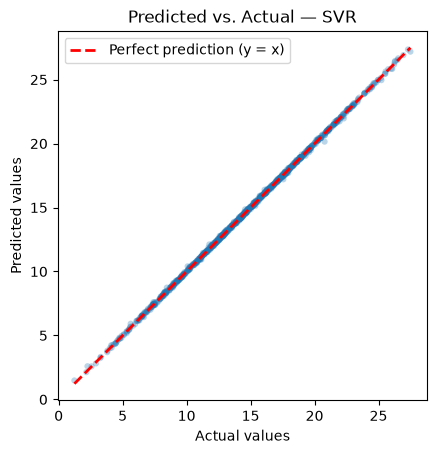

In [ ]:
#changed c from 1 to 100, significantly improved rmse test/train from .34/.32 to .07/.05
model = SVR(kernel='rbf',C=100, epsilon=0.1)
X_train, X_test, y_train, y_test = train_test_split(X_df, y_series, test_size=0.2, random_state=315)
model.fit(X_train, y_train)


y_pred_test = model.predict(X_test)
rmse_test = root_mean_squared_error(y_test, y_pred_test)
print(f'rmse for test = {rmse_test}')

y_pred_train = model.predict(X_train)
rmse_train = root_mean_squared_error(y_train, y_pred_train)
print(f'rmse for train = {rmse_train}')

plt.scatter(y_test, y_pred_test, alpha=0.3, edgecolors='none', s=20)

lims = [min(y_test.min(), y_pred_test.min()),
        max(y_test.max(), y_pred_test.max())]
plt.plot(lims, lims, color='red', linestyle='--', linewidth=2,
         label='Perfect prediction (y = x)')

plt.xlabel('Actual values')
plt.ylabel('Predicted values')
plt.title('Predicted vs. Actual — SVR')
plt.legend()
plt.axis('square') 
plt.show()

In [11]:
row = pd.DataFrame([{'model': 'SVR', 'train_rmse': rmse_train, 'test_rmse': rmse_test}])
row.to_csv('results.csv', mode='a', header=not os.path.exists('results.csv'), index=False)